## EDA and model development on Iris dataset

In [23]:
import pandas as pd

# load dataset
df = pd.read_csv("../../data/IRIS.csv") #index_col=0 if index

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### create model

In [24]:
# also linear regression does not need scaliing

from sklearn.model_selection import train_test_split

X, y = df.drop("species", axis=1), df["species"]

y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object

In [25]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [26]:
# train test split:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((100, 4), (50, 4))

In [27]:
# train model (y_pred vs y_test)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       0.94      1.00      0.97        15
 Iris-virginica       1.00      0.94      0.97        16

       accuracy                           0.98        50
      macro avg       0.98      0.98      0.98        50
   weighted avg       0.98      0.98      0.98        50



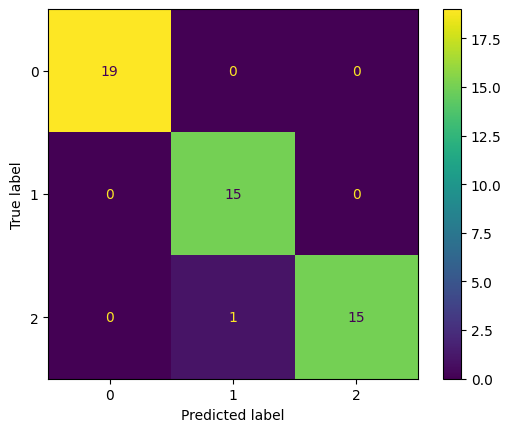

In [28]:
# compare and evaluate

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))

cm =(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay(cm).plot();

## Procedures to pick out a model:

0. explore and clean data set

1. do the sklearn steps
- train test split
- scale data if needed (RF not needed)
- train on train data
- predict on test data
- evaluate on test data

2. Repeat step 1 for several different models

3. Pick the model that scored the best for your particular data set

4. Use the best model and train on all data (both train and test data)

5. Export this trained model with joblib (file format for weighted parametres)

In [29]:
# 4 Use the best model (RF in this case) model_RF, model_linear

model.fit(X,y) #full data in X and y. not split yet

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
# 5 export data

import joblib

joblib.dump(model, "models/iris_classifier.joblib")

['models/iris_classifier.joblib']

## Testing IrisInput

In [31]:
from data_processing import IrisInput

payload = IrisInput(sepal_width=6.1, sepal_length=2.8, petal_width=1.3, petal_length=4.3)

payload

IrisInput(sepal_length=2.8, sepal_width=6.1, petal_length=4.3, petal_width=1.3)

In [32]:
[payload.model_dump()]

[{'sepal_length': 2.8,
  'sepal_width': 6.1,
  'petal_length': 4.3,
  'petal_width': 1.3}]

In [33]:
pd.DataFrame([payload.model_dump()])

,sepal_length,sepal_width,petal_length,petal_width
0,2.8,6.1,4.3,1.3


## Testing a Post request in python

In [36]:
import requests

url = "http://127.0.0.1:8000/api/predict"
payload = {
    'sepal_length': 2.8,
    'sepal_width': 6.1,
    'petal_length': 4.3,
    'petal_width': 1.3
    
}

response = requests.post(url=url, json=payload)
response

<Response [500]>

In [35]:
response.json()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
response = requests.get(url="http://127.0.0.1:8000/api/")
pd.DataFrame(response.json()).head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
